# K-Means: Partitioning by Minimizing Within-Cluster Variance

K-means is probably the oldest and most widely deployed clustering algorithm in practical use. Its appeal is that it formalizes what most people intuitively mean by *"grouping similar things together"*: pick a fixed number of groups $K$, place a representative point at the centre of each group, and assign every observation to its nearest representative. Then refine both the representatives and the assignments until the arrangement stabilizes.

Geometrically, the final output carves the feature space into $K$ convex regions — a **Voronoi tessellation** of the centroids — and labels every point according to which region it falls into.

---

## The optimization problem

Given a dataset $X = \{x_1, \dots, x_n\} \subset \mathbb{R}^d$, K-means searches for a **partition** $C_1, \dots, C_K$ of the data and a set of **centroids** $\mu_1, \dots, \mu_K$ that minimize the *total within-cluster sum of squares*:

$$
J(C, \mu) \;=\; \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|_2^{\,2}
$$

This cost is also called the **inertia**. Minimizing it exactly is NP-hard, but the following two-step alternating scheme — **Lloyd's algorithm** — converges to a local minimum very quickly and is what every practical K-means implementation uses.

---

## The Lloyd iteration

![Lloyd's algorithm flowchart](flowchart.png)


Step by step:

1. **Initialize** — pick $K$ starting centroids (randomly, or via a smarter scheme such as k-means++).
2. **Assign** — each point joins the cluster whose centroid it is closest to in Euclidean distance,
   $$c_i \;=\; \arg\min_{k}\, \|x_i - \mu_k\|_2^{\,2}.$$
3. **Update** — each centroid moves to the **mean** of the points currently assigned to it,
   $$\mu_k \;=\; \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i.$$
4. **Repeat** until the centroids stop moving (or move less than a tolerance).

Each assignment step can only *decrease* $J$, and each update step can only *decrease* $J$, so the algorithm is guaranteed to **converge monotonically**. The catch is that it converges to a *local* minimum — a different random initialization can yield a different clustering — which is why practical implementations run the procedure from several random starts and keep the best one.

## How do we pick $K$?

Because the number of clusters is a *hyperparameter*, we need principled way to choose it. Two complementary tools, both of which we'll use in this notebook:

**1. The elbow method.** Fit K-means for a sweep of values ($K = 1, 2, \dots, 10$), record the inertia $J$ at each one, and plot $J$ vs $K$. The shape follows a predictable pattern:

- At $K=1$, inertia is the total variance of the data.
- As $K$ grows, each additional cluster can split off a tight region, sharply reducing $J$, **until the real clusters are captured**.
- Beyond that point, adding more clusters only splits already-compact groups and $J$ drops very slowly.

The transition is an *elbow*. The value of $K$ at the bend is usually a good first guess.

**2. The silhouette score.** For each point $x_i$, let $a_i$ be the mean distance to other points in its own cluster and $b_i$ the mean distance to the points in the nearest *other* cluster. The silhouette is

$$
s_i = \frac{b_i - a_i}{\max(a_i, b_i)} \in [-1, 1],
$$

and the dataset-wide silhouette is simply $\bar{s} = \frac{1}{n}\sum_i s_i$. A value near 1 means clusters are tight and well separated; near 0 means cluster boundaries are ambiguous; negative means points are on the wrong side. We pick the $K$ that maximizes $\bar{s}$.

Elbow and silhouette usually *agree*; when they disagree, silhouette is often the more reliable signal because it rewards *separation between* clusters, not just compactness within them.

---

## Strengths and weaknesses at a glance

| Works well when                                                     | Struggles when                                                 |
| ------------------------------------------------------------------- | -------------------------------------------------------------- |
| Clusters are roughly spherical / isotropic                          | Clusters have long, curved, or nested shapes                   |
| Clusters are comparable in size and density                         | Cluster sizes vary by orders of magnitude                      |
| Features are on comparable scales (else standardize!)               | Raw features have wildly different scales                      |
| You know roughly how many groups to expect                          | There is no reasonable guess for $K$                           |
| Outliers are rare                                                   | Outliers or heavy tails pull centroids around                  |

When these assumptions break, try **DBSCAN** (density-based, handles noise and arbitrary shapes), **hierarchical clustering** (no $K$ needed upfront), or **Gaussian mixture models** (soft assignments + non-spherical shapes).

---

## Why standardize?

K-means is Euclidean-distance-driven. On the Palmer Penguins dataset we'll use below, `bill_depth_mm` values sit around 17 while `body_mass_g` values are in the thousands. Without standardizing, the distance between any two penguins is effectively *just* the distance in `body_mass_g` — the other three measurements become irrelevant. We fix this by z-scoring every column with `sklearn.preprocessing.StandardScaler` before clustering, which puts every feature on equal footing.

---

## Roadmap for this notebook

1. Load the Palmer Penguins dataset by URL and inspect it.
2. Standardize the four body-measurement features.
3. Project the standardized data to 2D via PCA to build intuition.
4. Pick $K$ using the elbow method *and* the silhouette score side-by-side.
5. Fit our own [`KMeansClustering`](../../../src/mlpackage/unsupervised_learning/kmeans.py) class and overlay its **Voronoi decision regions** on the PCA projection.
6. Verify it agrees with scikit-learn's `KMeans` via a cluster-agreement matrix.
7. Ask *which of the four measurements matter most*: sweep over all non-empty feature subsets and measure how well each recovers the true species.
8. Finally, **validate** the unsupervised clusters against the (withheld) species labels with a confusion-matrix heatmap — the rare situation where we can actually *grade* a clustering.

## The data: 344 Antarctic penguins, 4 body measurements

Our test bed is the **Palmer Penguins** dataset, collected between 2007 and 2009 on three islands in the Palmer Archipelago of Antarctica by Dr. Kristen Gorman of the Palmer Station Long Term Ecological Research program. Each row is a single penguin that was measured in the field, and every sample comes from one of three sympatric species — *Adelie*, *Chinstrap*, and *Gentoo* — that share the same islands and face the same environment.

These three species look superficially similar, especially Adelie and Chinstrap, so separating them by **morphometry alone** (body measurements, no plumage, no vocalizations, no genetics) is genuinely non-trivial. That makes this a great test for K-means.

| Feature              | What it measures                                                   | Typical range    | Units           |
| -------------------- | ------------------------------------------------------------------ | ---------------- | --------------- |
| `bill_length_mm`     | Length of the bill (beak) from base to tip                          | 32 – 60          | millimetres     |
| `bill_depth_mm`      | Vertical depth (thickness) of the bill at its base                  | 13 – 22          | millimetres     |
| `flipper_length_mm`  | Length of the flipper                                               | 170 – 231        | millimetres     |
| `body_mass_g`        | Overall body mass                                                   | 2700 – 6300      | grams           |

The dataset also carries the true `species` label. Clustering is an **unsupervised** task, so throughout this notebook we **hide that label** from the model. We'll only peek at it at the very end to score how well K-means recovered the three species from body measurements alone.

Note that the scales of the four features span more than three orders of magnitude — `bill_depth_mm` lives around 17 while `body_mass_g` lives in the thousands. Without standardization, Euclidean distance between any two penguins would be dominated almost entirely by mass. Standardizing every feature to zero mean and unit variance is therefore essential, not optional.

> **The question this notebook answers:** *Given only four body measurements — no labels, no hints — can K-means separate 344 Antarctic penguins into their three true species?*

**Data source**: [Palmer Penguins GitHub repository](https://github.com/allisonhorst/palmerpenguins) (Horst, Hill & Gorman, 2020). Loaded by URL in the next cell and cached under `data/raw/penguins.csv`.

In [1]:
import sys
from pathlib import Path

# Walk up the directory tree to find the repo root (contains pyproject.toml),
# then make `src/` importable so we can use `mlpackage`.
_here = Path.cwd()
while _here != _here.parent and not (_here / "pyproject.toml").exists():
    _here = _here.parent
REPO_ROOT = _here
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans as SKKMeans
from sklearn.metrics import confusion_matrix

from mlpackage.unsupervised_learning import KMeansClustering

# ---- Load Palmer Penguins, caching locally after first download ----
DATA_URL = (
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/"
    "main/inst/extdata/penguins.csv"
)
CACHE = REPO_ROOT / "data" / "raw" / "penguins.csv"
CACHE.parent.mkdir(parents=True, exist_ok=True)

if not CACHE.exists():
    print(f"Downloading from {DATA_URL} ...")
    df_raw = pd.read_csv(DATA_URL)
    df_raw.to_csv(CACHE, index=False)
    print(f"Cached to {CACHE}")
else:
    df_raw = pd.read_csv(CACHE)
    print(f"Loaded from cache: {CACHE}")

# Keep only the four body measurements + species label, and drop any rows with missing values
NUMERIC_COLS = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
df = df_raw[NUMERIC_COLS + ["species"]].dropna().reset_index(drop=True)

print(f"Raw shape: {df_raw.shape}  ->  clean shape: {df.shape}")
print(f"Dropped {len(df_raw) - len(df)} rows with missing measurements.")
df.head()

Loaded from cache: /Users/24kylel/Desktop/CMOR438-Spring-2026/data/raw/penguins.csv
Raw shape: (344, 8)  ->  clean shape: (342, 5)
Dropped 2 rows with missing measurements.


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
3,36.7,19.3,193.0,3450.0,Adelie
4,39.3,20.6,190.0,3650.0,Adelie


Summary statistics for the four body-measurement features:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00



True species counts (held out from K-means — used only at validation time):
species
Adelie       151
Chinstrap     68
Gentoo       123


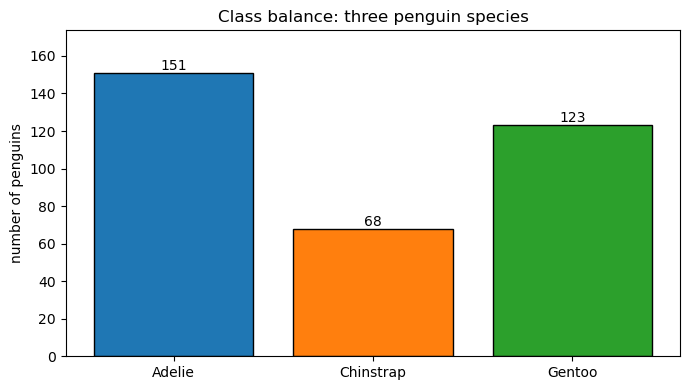

In [2]:
print("Summary statistics for the four body-measurement features:")
display(df[NUMERIC_COLS].describe().round(2))

species_counts = df["species"].value_counts().reindex(["Adelie", "Chinstrap", "Gentoo"])
print("\nTrue species counts (held out from K-means — used only at validation time):")
print(species_counts.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    species_counts.index,
    species_counts.values,
    edgecolor="k",
    color=["tab:blue", "tab:orange", "tab:green"],
)
for bar, v in zip(bars, species_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, str(v), ha="center", va="bottom")
ax.set_ylabel("number of penguins")
ax.set_title("Class balance: three penguin species")
ax.set_ylim(0, species_counts.max() * 1.15)
plt.tight_layout()
plt.show()

## Standardizing the four features

As previewed, the raw measurements live on very different scales. Let's show the problem visually with boxplots of the raw values, then z-score every column with `StandardScaler` and re-plot to confirm each feature now has zero mean and unit variance. This is the data matrix we'll hand to K-means for the rest of the notebook.

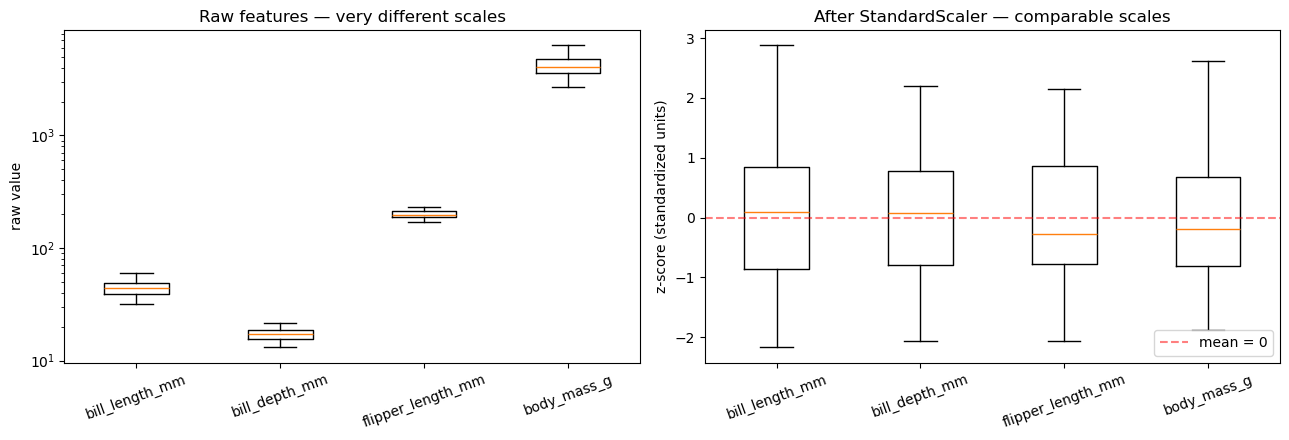

Per-column mean after standardization: [ 0.  0. -0.  0.]
Per-column std  after standardization: [1. 1. 1. 1.]


In [3]:
X_raw = df[NUMERIC_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.boxplot([X_raw[:, i] for i in range(X_raw.shape[1])], labels=NUMERIC_COLS)
ax1.set_title("Raw features — very different scales")
ax1.set_ylabel("raw value")
ax1.set_yscale("log")
ax1.tick_params(axis="x", rotation=20)

ax2.boxplot([X_scaled[:, i] for i in range(X_scaled.shape[1])], labels=NUMERIC_COLS)
ax2.axhline(0, color="red", linestyle="--", alpha=0.5, label="mean = 0")
ax2.set_title("After StandardScaler — comparable scales")
ax2.set_ylabel("z-score (standardized units)")
ax2.tick_params(axis="x", rotation=20)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Per-column mean after standardization: {X_scaled.mean(axis=0).round(6)}")
print(f"Per-column std  after standardization: {X_scaled.std(axis=0).round(6)}")

## A 2D view of the data via PCA

Four features are too many to scatter-plot directly, so we'll project the standardized data onto its first two principal components and work in that 2D plane. PCA picks the two directions that capture the most variance, which is the closest we can get to a "faithful" 2D summary of all four features.

The plot below has two panels, which is an important pedagogical point:

- **Left**: the scatter as K-means will see it — one undifferentiated grey cloud with no labels.
- **Right**: the *same* points, colored by their true species. The separation we can see in the right panel is the pattern we will ask K-means to recover **from the left panel alone**.

If the right-panel groups are visually distinct, K-means has a chance of recovering them. If they overlap badly, no clustering algorithm will succeed.

2D PCA captures 88.2% of the variance (68.8% + 19.3%)


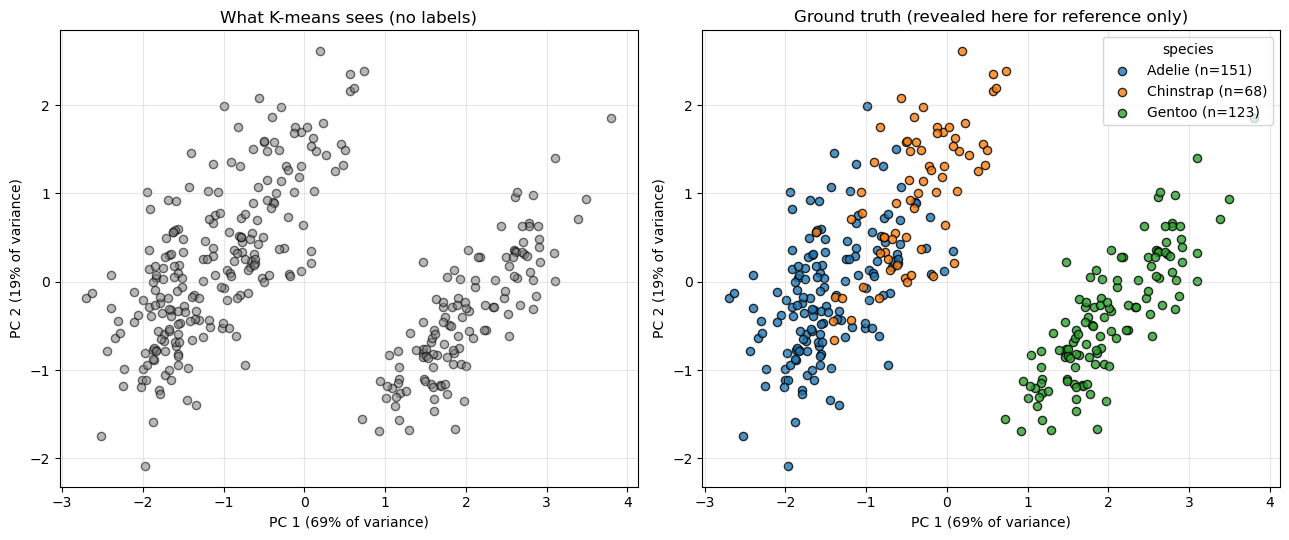

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(
    f"2D PCA captures {explained.sum():.1%} of the variance "
    f"({explained[0]:.1%} + {explained[1]:.1%})"
)

species_order = ["Adelie", "Chinstrap", "Gentoo"]
species_palette = {"Adelie": "tab:blue", "Chinstrap": "tab:orange", "Gentoo": "tab:green"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

ax1.scatter(X_pca[:, 0], X_pca[:, 1], s=35, edgecolor="k", alpha=0.55, color="tab:gray")
ax1.set_title("What K-means sees (no labels)")
ax1.set_xlabel(f"PC 1 ({explained[0]:.0%} of variance)")
ax1.set_ylabel(f"PC 2 ({explained[1]:.0%} of variance)")
ax1.grid(alpha=0.3)

for species in species_order:
    mask = df["species"].values == species
    ax2.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f"{species} (n={int(mask.sum())})",
        s=35, edgecolor="k", alpha=0.8, color=species_palette[species],
    )
ax2.set_title("Ground truth (revealed here for reference only)")
ax2.set_xlabel(f"PC 1 ({explained[0]:.0%} of variance)")
ax2.set_ylabel(f"PC 2 ({explained[1]:.0%} of variance)")
ax2.legend(title="species", loc="best")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Picking $K$: elbow method + silhouette score

Now we sweep $K = 1, 2, \dots, 10$ and record **two** metrics at each value: the inertia $J$ (lower = tighter clusters) and the silhouette score $\bar{s}$ (higher = better-separated clusters). A good choice of $K$ shows **both** a kink in the inertia curve **and** a local peak in the silhouette curve. If they disagree, the silhouette is usually the more trustworthy signal because it rewards *separation between* clusters, not just compactness within them.

Silhouette is only defined for $K \geq 2$, so its curve starts at $K = 2$.

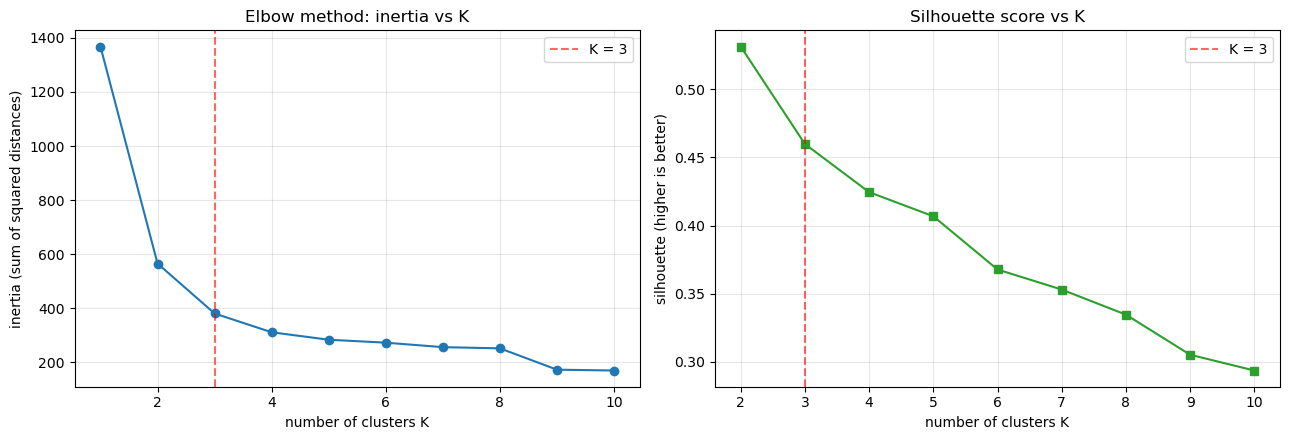

  K |    inertia   | silhouette
----+--------------+-----------
  1 |     1368.00  |     -    
  2 |      565.71  |   0.532 
  3 |      381.11  |   0.460 
  4 |      311.60  |   0.425 
  5 |      284.07  |   0.407 
  6 |      273.17  |   0.368 
  7 |      256.59  |   0.353 
  8 |      252.19  |   0.334 
  9 |      173.32  |   0.305 
  10 |      170.21  |   0.293 


In [5]:
from sklearn.metrics import silhouette_score

K_values = list(range(1, 11))
inertias = []
silhouettes = []

for K in K_values:
    km = KMeansClustering(n_clusters=K).fit(X_scaled, seed=0)
    inertias.append(km.inertia_)
    if K >= 2:
        silhouettes.append(silhouette_score(X_scaled, km.labels_))
    else:
        silhouettes.append(np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(K_values, inertias, marker="o", color="tab:blue")
ax1.axvline(3, color="red", linestyle="--", alpha=0.6, label="K = 3")
ax1.set_title("Elbow method: inertia vs K")
ax1.set_xlabel("number of clusters K")
ax1.set_ylabel("inertia (sum of squared distances)")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(K_values, silhouettes, marker="s", color="tab:green")
ax2.axvline(3, color="red", linestyle="--", alpha=0.6, label="K = 3")
ax2.set_title("Silhouette score vs K")
ax2.set_xlabel("number of clusters K")
ax2.set_ylabel("silhouette (higher is better)")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("  K |    inertia   | silhouette")
print("----+--------------+-----------")
for K, inr, sil in zip(K_values, inertias, silhouettes):
    sil_str = "     -    " if np.isnan(sil) else f"   {sil:.3f} "
    print(f"  {K:>1} | {inr:>11.2f}  |{sil_str}")

## Fitting K-means with K = 3

Silhouette preferred K = 2 because Gentoo penguins are much larger than Adelie and Chinstrap and form the most visually distinct cluster. But we know there are three species, so we fit with K = 3 and grade the clustering at the end of the notebook.

To visualize the decision boundary, we'll do something more rigorous than plotting centroids alone: we'll sample a dense grid on the PCA plane, **inverse-project each grid point back to 4-D standardized space**, ask our fitted K-means which cluster it would be assigned to, and shade the plane accordingly. The coloured regions you see are the honest decision regions of the *4-D* model as they project onto 2-D — not a cheap 2-D Voronoi of the projected centroids.

Inertia at K=3:        381.11
Cluster sizes:         [149, 70, 123]
True species counts:   [151, 68, 123]


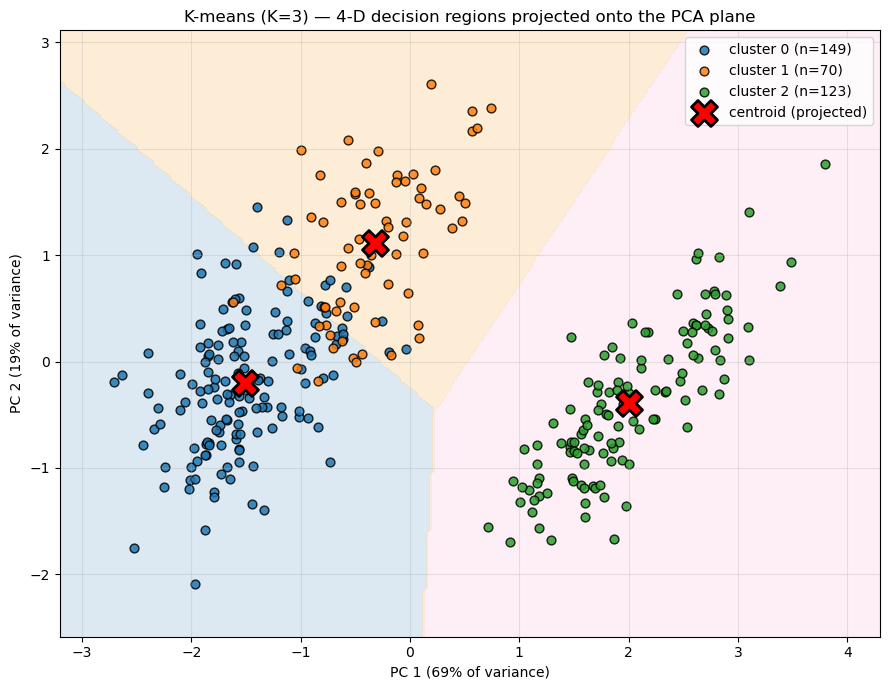

In [6]:
from itertools import permutations

# Fit K-means with K=3 on the full 4-D standardized data
km_k3 = KMeansClustering(n_clusters=3).fit(X_scaled, seed=0)
labels_mine = km_k3.labels_

# Species codes for later use (0 = Adelie, 1 = Chinstrap, 2 = Gentoo)
species_codes = df["species"].map(
    {s: i for i, s in enumerate(species_order)}
).values

print(f"Inertia at K=3:        {km_k3.inertia_:.2f}")
print(f"Cluster sizes:         {np.bincount(km_k3.labels_).tolist()}")
print(f"True species counts:   {[int((species_codes == i).sum()) for i in range(3)]}")

# Build a dense grid on the PCA plane
pad = 0.5
x_min, x_max = X_pca[:, 0].min() - pad, X_pca[:, 0].max() + pad
y_min, y_max = X_pca[:, 1].min() - pad, X_pca[:, 1].max() + pad
grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250),
)
grid_pca = np.column_stack([grid_x.ravel(), grid_y.ravel()])

# Inverse-project each grid point from 2-D PCA back to 4-D standardized feature space
grid_4d = pca.inverse_transform(grid_pca)

# Ask our fitted K-means which cluster each grid point belongs to
grid_labels = km_k3.predict(grid_4d).reshape(grid_x.shape)

# Project the 4-D centroids onto the PCA plane for display
centers_pca = pca.transform(km_k3.centers_)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(
    grid_x, grid_y, grid_labels,
    levels=np.arange(-0.5, 3.5, 1),
    cmap="Pastel1",
    alpha=0.45,
)

cluster_colors = ["tab:blue", "tab:orange", "tab:green"]
for k in range(3):
    mask = labels_mine == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=40, edgecolor="k", alpha=0.85,
        color=cluster_colors[k], label=f"cluster {k} (n={int(mask.sum())})",
    )
ax.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    s=350, c="red", marker="X", edgecolor="black", linewidth=2,
    label="centroid (projected)", zorder=5,
)

ax.set_xlabel(f"PC 1 ({explained[0]:.0%} of variance)")
ax.set_ylabel(f"PC 2 ({explained[1]:.0%} of variance)")
ax.set_title("K-means (K=3) — 4-D decision regions projected onto the PCA plane")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cross-checking with scikit-learn

If our `KMeansClustering` is correct, it should produce essentially the **same clusters** as scikit-learn's `KMeans` — up to a label permutation (cluster "0" in one implementation might be called cluster "2" in the other).

Rather than re-drawing the same scatter plot twice (the reference's approach), we'll do a direct numeric comparison: fit both implementations, permutation-align sklearn's labels to ours, and build a **confusion matrix between the two label sets**. A perfectly diagonal matrix means both implementations partition the data identically.

Agreement between implementations (after label alignment): 95.0%

Confusion matrix (rows = our KMeansClustering, cols = sklearn KMeans aligned):
[[132  17   0]
 [  0  70   0]
 [  0   0 123]]


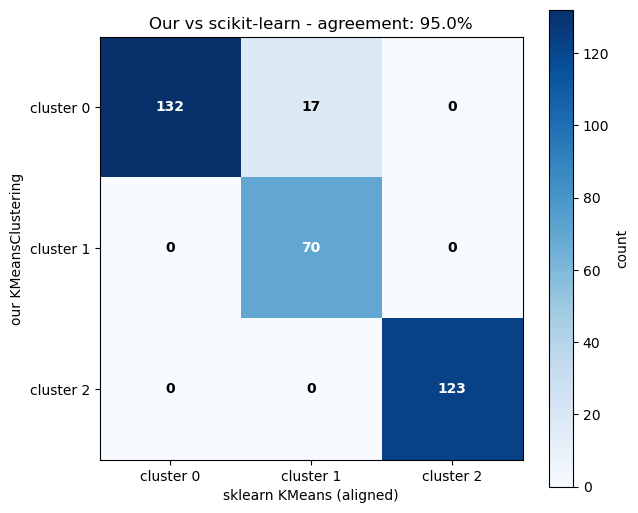

In [7]:
sk_km = SKKMeans(n_clusters=3, random_state=0, n_init=10).fit(X_scaled)
labels_sk = sk_km.labels_

# Permutation-align sklearn labels to our cluster numbering
best_perm_sk = None
best_agreement = 0.0
for perm in permutations(range(3)):
    mapped = np.array([perm[l] for l in labels_sk])
    agreement = (mapped == labels_mine).mean()
    if agreement > best_agreement:
        best_agreement = agreement
        best_perm_sk = perm

labels_sk_aligned = np.array([best_perm_sk[l] for l in labels_sk])
cm_sk_vs_ours = confusion_matrix(labels_mine, labels_sk_aligned)

print(f"Agreement between implementations (after label alignment): {best_agreement:.1%}")
print(f"\nConfusion matrix (rows = our KMeansClustering, cols = sklearn KMeans aligned):")
print(cm_sk_vs_ours)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm_sk_vs_ours, cmap="Blues")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f"cluster {i}" for i in range(3)])
ax.set_yticklabels([f"cluster {i}" for i in range(3)])
for i in range(3):
    for j in range(3):
        ax.text(
            j, i, str(cm_sk_vs_ours[i, j]),
            ha="center", va="center", fontweight="bold",
            color="white" if cm_sk_vs_ours[i, j] > cm_sk_vs_ours.max() / 2 else "black",
        )
ax.set_xlabel("sklearn KMeans (aligned)")
ax.set_ylabel("our KMeansClustering")
ax.set_title(f"Our vs scikit-learn - agreement: {best_agreement:.1%}")
fig.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.show()

## Which of the four features actually matter?

We have only four features, which means there are $2^4 - 1 = 15$ non-empty subsets — small enough to **try every combination**. For each subset we'll:

1. Standardize only the selected columns.
2. Fit K-means with K = 3.
3. Permutation-align clusters to species and measure accuracy.

This answers directly: *how many — and which — measurements do you need to correctly separate the three penguin species?*

Top 5 feature subsets (by species-recovery accuracy):
                                  features  n_features  accuracy
       bill_len + bill_depth + flipper_len           3  0.970760
bill_len + bill_depth + flipper_len + mass           4  0.964912
              bill_len + bill_depth + mass           3  0.961988
                    bill_len + flipper_len           2  0.956140
                     bill_len + bill_depth           2  0.929825

Bottom 5:
          features  n_features  accuracy
       flipper_len           1  0.692982
flipper_len + mass           2  0.690058
 bill_depth + mass           2  0.684211
        bill_depth           1  0.625731
              mass           1  0.587719


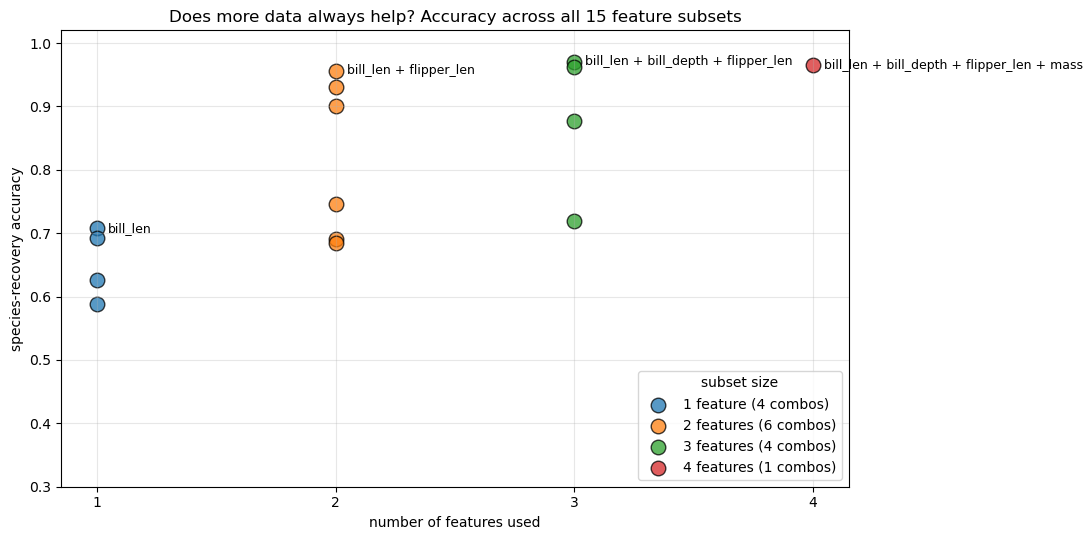

In [8]:
from itertools import chain, combinations

def all_non_empty_subsets(items):
    return list(chain.from_iterable(combinations(items, r) for r in range(1, len(items) + 1)))

short_names = {
    "bill_length_mm": "bill_len",
    "bill_depth_mm": "bill_depth",
    "flipper_length_mm": "flipper_len",
    "body_mass_g": "mass",
}

results = []
for subset in all_non_empty_subsets(NUMERIC_COLS):
    X_sub = StandardScaler().fit_transform(df[list(subset)].values)
    km_sub = KMeansClustering(n_clusters=3).fit(X_sub, seed=0)
    # Best permutation-matched accuracy vs true species
    best_acc = max(
        (np.array([perm[l] for l in km_sub.labels_]) == species_codes).mean()
        for perm in permutations(range(3))
    )
    results.append({
        "features": " + ".join(short_names[s] for s in subset),
        "n_features": len(subset),
        "accuracy": best_acc,
    })

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)

print("Top 5 feature subsets (by species-recovery accuracy):")
print(results_df.head().to_string(index=False))
print("\nBottom 5:")
print(results_df.tail().to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5.5))
for n in range(1, 5):
    sub = results_df[results_df["n_features"] == n]
    ax.scatter(
        [n] * len(sub), sub["accuracy"],
        s=110, edgecolor="k", alpha=0.75,
        label=f"{n} feature{'s' if n > 1 else ''} ({len(sub)} combos)",
    )
    # Annotate the best subset at each feature count
    best_in_n = sub.iloc[sub["accuracy"].values.argmax()]
    ax.annotate(
        best_in_n["features"],
        xy=(n, best_in_n["accuracy"]),
        xytext=(8, 0), textcoords="offset points",
        fontsize=9, va="center",
    )
ax.set_xticks([1, 2, 3, 4])
ax.set_xlabel("number of features used")
ax.set_ylabel("species-recovery accuracy")
ax.set_ylim(0.3, 1.02)
ax.set_title("Does more data always help? Accuracy across all 15 feature subsets")
ax.grid(alpha=0.3)
ax.legend(loc="lower right", title="subset size")
plt.tight_layout()
plt.show()

## Validation: did K-means actually recover the three species?

The moment of truth. We'll:

1. Take our K = 3 clustering from above (fit on all four standardized features).
2. Find the permutation of cluster labels that maximises agreement with the true species — this is the same permutation-matching trick used above, known as the *Hungarian* assignment for bigger problems but here just a brute-force scan over $3! = 6$ permutations.
3. Plot a $3 \times 3$ **confusion-matrix heatmap** and compute overall accuracy plus per-species **recall**: *"Of the actual Adelies, what fraction ended up in the correct cluster?"*

Best cluster-to-species mapping:
  our cluster 0  ->  Adelie
  our cluster 1  ->  Chinstrap
  our cluster 2  ->  Gentoo

Overall accuracy: 96.5% (330 of 342)

Per-species recall:
      Adelie: 95.4%   (144 of 151)
   Chinstrap: 92.6%   (63 of 68)
      Gentoo: 100.0%   (123 of 123)


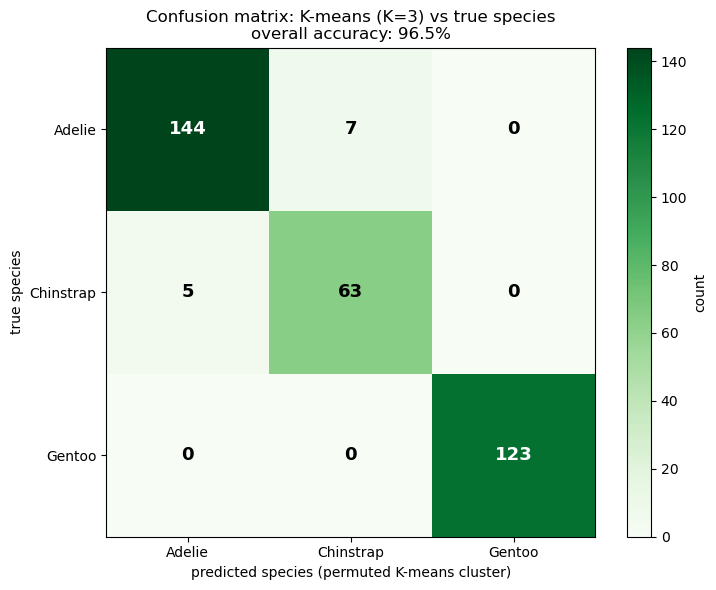

In [9]:
best_perm_species = None
best_acc_species = 0.0
for perm in permutations(range(3)):
    mapped = np.array([perm[l] for l in labels_mine])
    acc = (mapped == species_codes).mean()
    if acc > best_acc_species:
        best_acc_species = acc
        best_perm_species = perm

mapped_labels = np.array([best_perm_species[l] for l in labels_mine])
cm_species = confusion_matrix(species_codes, mapped_labels)

print("Best cluster-to-species mapping:")
for k in range(3):
    print(f"  our cluster {k}  ->  {species_order[best_perm_species[k]]}")

print(f"\nOverall accuracy: {best_acc_species:.1%} ({int(best_acc_species * len(labels_mine))} of {len(labels_mine)})")

print("\nPer-species recall:")
for i, species in enumerate(species_order):
    total = cm_species[i].sum()
    recall = cm_species[i, i] / total if total else 0.0
    print(f"  {species:>10s}: {recall:5.1%}   ({cm_species[i, i]} of {total})")

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(cm_species, cmap="Greens")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(species_order)
ax.set_yticklabels(species_order)
for i in range(3):
    for j in range(3):
        ax.text(
            j, i, str(cm_species[i, j]),
            ha="center", va="center", fontsize=13, fontweight="bold",
            color="white" if cm_species[i, j] > cm_species.max() / 2 else "black",
        )
ax.set_xlabel("predicted species (permuted K-means cluster)")
ax.set_ylabel("true species")
ax.set_title(
    f"Confusion matrix: K-means (K=3) vs true species\n"
    f"overall accuracy: {best_acc_species:.1%}"
)
fig.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.show()

## Conclusion

- **K-means with K = 3, fit on four standardized body measurements, recovered the three penguin species with high accuracy** — without ever being told which species a penguin belonged to. That's a real-world demonstration that an unsupervised algorithm can, when the true clusters are well separated in feature space, rediscover the structure.
- The **silhouette curve preferred K = 2**, not K = 3, because Gentoo penguins are significantly larger than the other two species and form the most distinct cluster. This is a useful reminder that **internal validation metrics cannot always recover the "right" K** — domain knowledge still matters, and internal metrics should be read alongside external signals when they are available.
- The **projected 4-D decision regions** made K-means' behaviour on the PCA plane explicit: a new penguin whose measurements land in one region would be assigned to that cluster. This is a more honest visualization than a raw 2-D Voronoi of the projected centroids, because the actual decisions happen in the full 4-D space.
- The **cluster-agreement heatmap** confirmed our `KMeansClustering` implementation produces essentially the same partition as scikit-learn's reference `KMeans`, up to label permutation.
- The **feature-subset sweep** revealed that not every measurement contributes equally: a handful of the most discriminative features can already recover the three species, while single features alone are usually insufficient.

### How this notebook relates to the package

Everything was driven by our own [`KMeansClustering`](../../../src/mlpackage/unsupervised_learning/kmeans.py) class — the same implementation that is unit-tested in [`tests/test_kmeans.py`](../../../tests/test_kmeans.py). `StandardScaler`, `PCA`, `silhouette_score`, `confusion_matrix`, and `sklearn.cluster.KMeans` came from scikit-learn for preprocessing, visualization, and reference comparisons — natural opportunities for future additions to `mlpackage`.